# Neural Network Exercise

We will use the car data to build a neural network to predict MPG. We will start by importing and cleaning up the dataset. Then we will fit a neural network with a single input and a single layer. Then we will fit a deep neural network to the single variable. Finally, you will fit a deep neural network on the full set of explanatory variables. As we go we will compare the error rates and run time to summarize the model design tradeoffs. 

In [33]:
# If you have not yet installed the tensorflow package, you can uncomment this code to do so. 

# ! pip install tensorflow

  Created wheel for ann-visualizer: filename=ann_visualizer-2.5-py3-none-any.whl size=4168 sha256=1da23d54903db8d74acd3d1ca9854c963861a3fcf70fd4347d66b44ed906a0f2
  Stored in directory: c:\users\jhollad3\appdata\local\pip\cache\wheels\4b\ef\77\9b8c4ae2f9a11de19957b80bc5c684accd99114bb8dc6b374c
Successfully built ann-visualizer


In [13]:
# Import the utility pacakges we need
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split


# Make NumPy printouts easier to read.
np.set_printoptions(precision=3, suppress=True)


# Import the neural network packages we need
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras_visualizer import visualizer 

In [3]:
# Import and clean up the data. 
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                'Acceleration', 'Model Year', 'Origin']

df = pd.read_csv(url, names=column_names,
                          na_values='?', comment='\t',
                          sep=' ', skipinitialspace=True)

print(df.isna().sum())
df = df.dropna()

df = pd.get_dummies(df, columns=['Origin'], prefix='', prefix_sep='')
df.head()

MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,1,2,3
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,0,0
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,0,0
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,0,0
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,0,0
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,0,0


In [4]:
# Create our dataset using stat/econ naming conventions

y=df.MPG
X=df.drop(columns=['MPG'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=50)

In [5]:
## Normalize the data - NN run better on data that has been demeaned. 
normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(np.array(X_train))
print(normalizer.mean.numpy())

first = np.array(X_train[:1])

with np.printoptions(precision=2, suppress=True):
  print('First example:', first)
  print('Normalized:', normalizer(first).numpy())

[[   5.371  188.968  102.673 2936.292   15.703   76.252    0.599    0.173
     0.228]]
First example: [[   6.  250.   78. 3574.   21.   76.    1.    0.    0.]]
Normalized: [[ 0.37  0.58 -0.64  0.75  1.9  -0.07  0.82 -0.46 -0.54]]


In [6]:
horsepower = np.array(X_train['Horsepower'])             # Define the explanatory variable

horsepower_normalizer = layers.Normalization(input_shape=[1,], axis=None)
horsepower_normalizer.adapt(horsepower)


#Build the Keras Sequential model:
horsepower_model = tf.keras.Sequential([
    horsepower_normalizer,
    layers.Dense(units=1)
])

horsepower_model.summary()
horsepower_model.predict(horsepower[:10])

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 normalization_1 (Normalizat  (None, 1)                3         
 ion)                                                            
                                                                 
 dense (Dense)               (None, 1)                 2         
                                                                 
Total params: 5
Trainable params: 2
Non-trainable params: 3
_________________________________________________________________


array([[-0.01 ],
       [-0.009],
       [-0.005],
       [ 0.003],
       [ 0.003],
       [-0.008],
       [-0.006],
       [-0.01 ],
       [-0.011],
       [-0.011]], dtype=float32)

In [7]:
horsepower_model.compile(
    optimizer=tf.optimizers.Adam(learning_rate=0.1),
    loss='mean_absolute_error')

In [8]:
%%time
history = horsepower_model.fit(
    X_train['Horsepower'],
    y_train,
    epochs=100,
    # Suppress logging.
    verbose=0,
    # Calculate validation results on 20% of the training data.
    validation_split = 0.2)

Wall time: 2.27 s


In [9]:
## Define functions to create a couple of graphs. First plot the learning of the model over time
# Then plot the data vs predictions. Call these two functions separately. 

def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  plt.ylim([0, 10])
  plt.xlabel('Epoch')
  plt.ylabel('Error [MPG]')
  plt.legend()
  plt.grid(True)

def plot_horsepower(x, y):
  plt.scatter(X_train['Horsepower'], y_train, label='Data')
  plt.plot(x, y, color='k', label='Predictions')
  plt.xlabel('Horsepower')
  plt.ylabel('MPG')
  plt.legend()

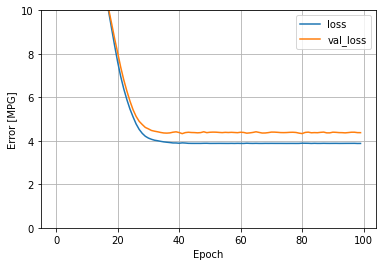

In [10]:
## Create the plot of how the model learned over time. 
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

plot_loss(history)

4/4 [==============================] - 0s 665us/step - loss: 3.3776


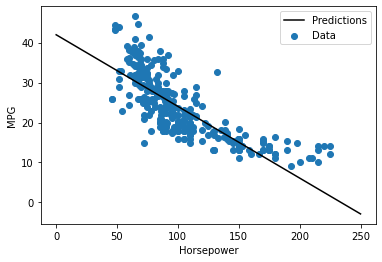

In [11]:
test_results = {}

test_results['horsepower_model'] = horsepower_model.evaluate(
    X_test['Horsepower'],
    y_test, verbose=1)

#We can visualize univariate regression easily:
x1 = tf.linspace(0.0, 250, 251)
y1 = horsepower_model.predict(x1)

plot_horsepower(x1, y1)

## Deeper Network

Now lets extend the model to a deeper network. Stick with horsepower as the only input and add 

In [14]:
# This fines a function that build and runs a deep neural network. You can either use this function for the exercise, 
# or copy this code to build the model yourself. 

def build_and_compile_model(norm):
  model = keras.Sequential([
      norm,
      layers.Dense(64, activation='relu'),
      layers.Dense(64, activation='relu'),
      layers.Dense(1)
  ])

  model.compile(loss='mean_absolute_error',
                optimizer=tf.keras.optimizers.Adam(0.001))
  return model

In [31]:
# Build the model and train
%%time
dnn_horsepower_model = build_and_compile_model(horsepower_normalizer)

dnn_horsepower_model.summary()

history = dnn_horsepower_model.fit(
    X_train['Horsepower'],
    y_train,
    validation_split=0.2,
    verbose=0, epochs=100)

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 normalization_1 (Normalizat  (None, 1)                3         
 ion)                                                            
                                                                 
 dense_7 (Dense)             (None, 64)                128       
                                                                 
 dense_8 (Dense)             (None, 64)                4160      
                                                                 
 dense_9 (Dense)             (None, 1)                 65        
                                                                 
Total params: 4,356
Trainable params: 4,353
Non-trainable params: 3
_________________________________________________________________
Wall time: 2.33 s


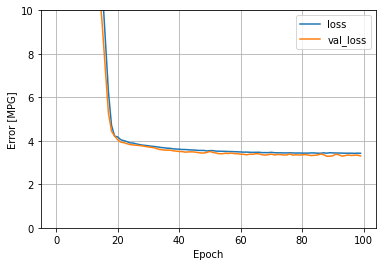

In [26]:
# Plot learning
plot_loss(history)

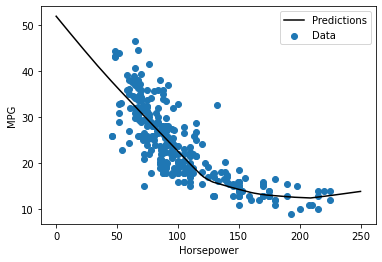

In [27]:
# Plot actual data vs predictions

x2 = tf.linspace(0.0, 250, 251)
y2 = dnn_horsepower_model.predict(x2)

plot_horsepower(x2, y2)

In [28]:
# Comile actual vs predictions and build a dataframe to hold the % error

test_results['dnn_horsepower_model'] = dnn_horsepower_model.evaluate(
    X_test['Horsepower'], y_test,
    verbose=0)

pd.DataFrame(test_results, index=['Mean absolute error [MPG]'])

## Exercise - Build your own DNN

Run the deep neurual network on the full set of X variables. Use the same network we used above, but modify it to use all the X variables. Keep track of the error rates and compare the performance of the three models in this notebook. 